In [24]:
import numpy as np

In [25]:
def theoretical_pi(p,q):
    return np.array([q/(p+q), p/(p+q)])

print(theoretical_pi(0.5,0.5))

[0.5 0.5]


In [26]:
print(theoretical_pi(1,1))

print(theoretical_pi(1,0.5))

print(theoretical_pi(0.5,1))

print(theoretical_pi(0.3, 0.5))

[0.5 0.5]
[0.33333333 0.66666667]
[0.66666667 0.33333333]
[0.625 0.375]


In [27]:
import numpy as np

def simulate_chain(p, q, steps=100000):

    state = 0
    counts = [0,0]

    for _ in range(steps):

        counts[state] += 1
        
        if state == 0:
            state = np.random.choice([0,1], p=[1-p, p])
        else:
            state = np.random.choice([0,1], p=[q, 1-q])

    return np.array(counts)/steps


print(simulate_chain(0.5,0.5))

[0.49943 0.50057]


In [31]:
print(simulate_chain(1,1))

print(simulate_chain(1,0.5))

print(simulate_chain(0.5,1))

print(simulate_chain(0.3, 0.5))

[0.5 0.5]
[0.33447 0.66553]
[0.665 0.335]
[0.62552 0.37448]


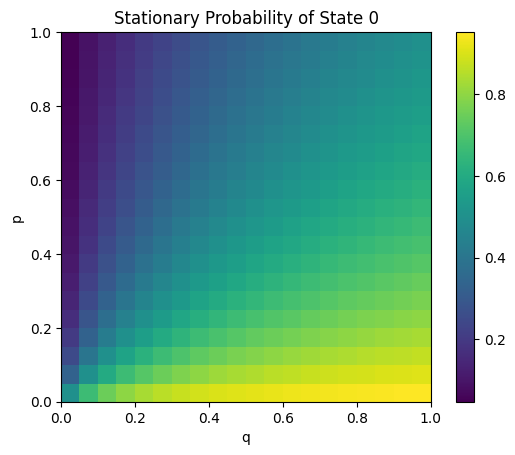

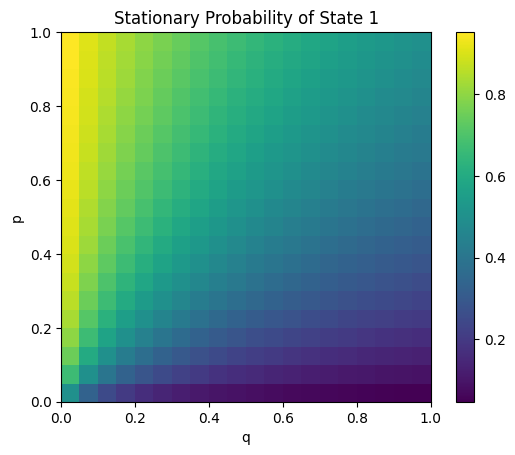

In [29]:
import numpy as np
import matplotlib.pyplot as plt

p_vals = np.linspace(0.05,1,20)
q_vals = np.linspace(0.05,1,20)

pi0 = np.zeros((20,20))
pi1 = np.zeros((20,20))

for i,p in enumerate(p_vals):
    for j,q in enumerate(q_vals):
        pi0[i,j] = q/(p+q)
        pi1[i,j] = p/(p+q)

plt.figure()
plt.imshow(pi0, extent=[0,1,0,1], origin='lower')
plt.colorbar()
plt.xlabel("q")
plt.ylabel("p")
plt.title("Stationary Probability of State 0")
plt.show()

plt.figure()
plt.imshow(pi1, extent=[0,1,0,1], origin='lower')
plt.colorbar()
plt.xlabel("q")
plt.ylabel("p")
plt.title("Stationary Probability of State 1")
plt.show()

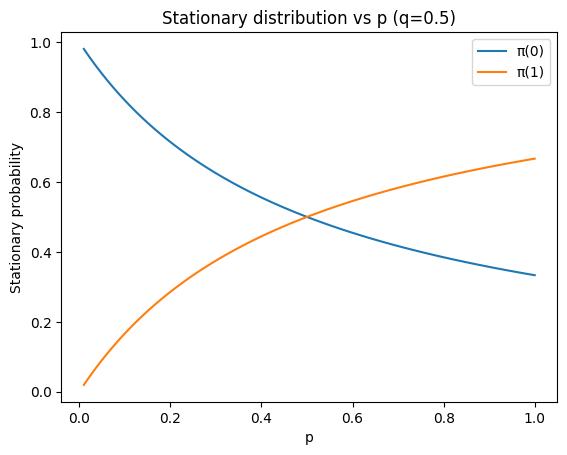

In [30]:
import numpy as np
import matplotlib.pyplot as plt

q = 0.5
p_vals = np.linspace(0.01,1,100)

pi0 = q/(p_vals + q)
pi1 = p_vals/(p_vals + q)

plt.figure()
plt.plot(p_vals, pi0, label="π(0)")
plt.plot(p_vals, pi1, label="π(1)")
plt.xlabel("p")
plt.ylabel("Stationary probability")
plt.title("Stationary distribution vs p (q=0.5)")
plt.legend()
plt.show()

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_markov_chain(p, q, steps=10000, start_state=0):

    state = start_state
    states = []

    for _ in range(steps):

        states.append(state)

        if state == 0:
            state = np.random.choice([0,1], p=[1-p, p])
        else:
            state = np.random.choice([0,1], p=[q, 1-q])

    return np.array(states)

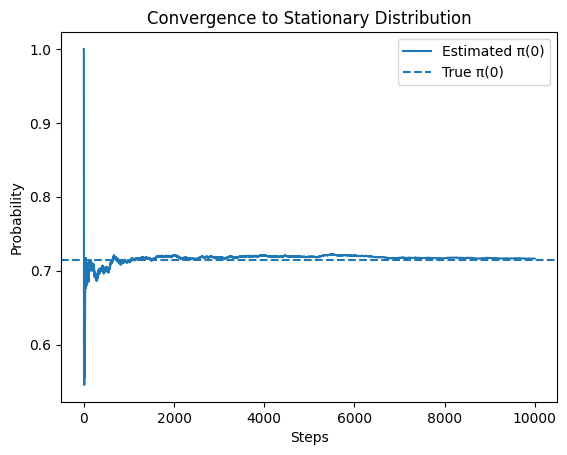

In [42]:
steps = 10000

p,q = 0.4,1.0

states = simulate_markov_chain(p,q,steps)

running_pi0 = []
count0 = 0

for i,state in enumerate(states):

    if state == 0:
        count0 += 1

    running_pi0.append(count0/(i+1))

theoretical_pi0 = q/(p+q)

plt.figure()
plt.plot(running_pi0, label="Estimated π(0)")
plt.axhline(theoretical_pi0, linestyle="--", label="True π(0)")
plt.xlabel("Steps")
plt.ylabel("Probability")
plt.title("Convergence to Stationary Distribution")
plt.legend()
plt.show()

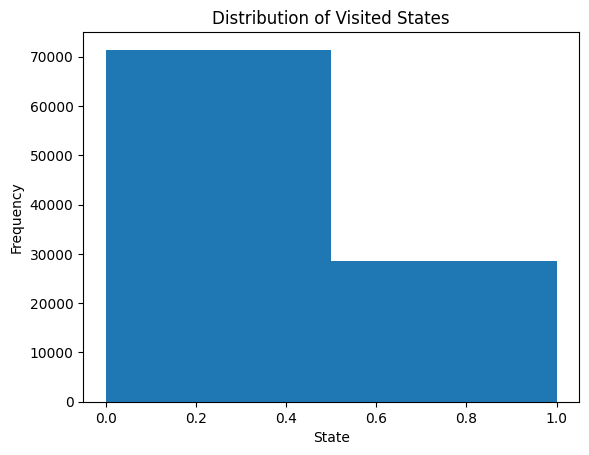

In [43]:
states = simulate_markov_chain(p,q,100000)

plt.figure()
plt.hist(states, bins=2)
plt.xlabel("State")
plt.ylabel("Frequency")
plt.title("Distribution of Visited States")
plt.show()

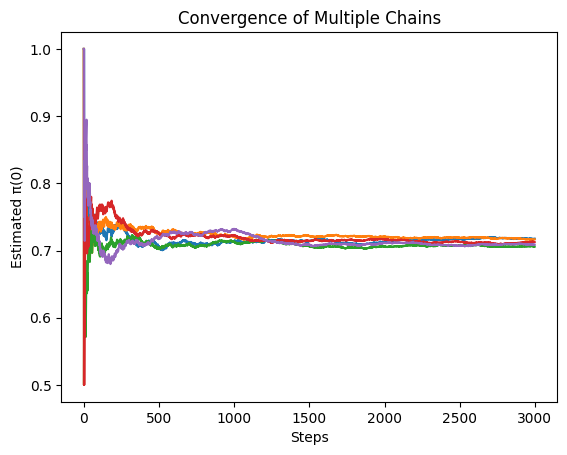

In [44]:
chains = []

for i in range(5):
    chains.append(simulate_markov_chain(p,q,3000))

plt.figure()

for chain in chains:
    running = np.cumsum(chain==0)/np.arange(1,len(chain)+1)
    plt.plot(running)

plt.xlabel("Steps")
plt.ylabel("Estimated π(0)")
plt.title("Convergence of Multiple Chains")
plt.show()